In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/ml_daily_features.parquet")

# ensuring date is DATETIME and year is INT
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["year"].astype(int)

df.head()
df.dtypes


site_id                    object
site_name                  object
pollutant                  object
unit                       object
date               datetime64[ns]
year                        int64
daily_median              float64
daily_mean                float64
roll7                     float64
roll30                    float64
norm_median               float64
delta_abs                 float64
delta_pct                 float64
z                         float64
exceed_pm25_who             int64
exceed_pm10_who             int64
dtype: object

In [2]:
def eval_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [3]:
df["pollutant"] = (
    df["pollutant"]
    .str.upper()
    .str.replace(" ", "")
    .str.replace(".", "")
)

In [4]:
df_pm25 = df[df["pollutant"] == "PM25"].copy()

df_pm25.shape
df_pm25["site_id"].nunique(), df_pm25["site_name"].nunique()

(18, 17)

In [5]:
df_pm25['site_name'].unique()
df_pm25.columns

Index(['site_id', 'site_name', 'pollutant', 'unit', 'date', 'year',
       'daily_median', 'daily_mean', 'roll7', 'roll30', 'norm_median',
       'delta_abs', 'delta_pct', 'z', 'exceed_pm25_who', 'exceed_pm10_who'],
      dtype='object')

In [6]:
# For each row, check: "is my (site_id, pollutant) group all missing in norm_median?"
all_missing_groups = (
    df_pm25
    .groupby(["site_id", "pollutant"])["norm_median"]
    .transform(lambda s: s.isna().all())
)

# Keep only groups that have at least one valid norm_median
df_pm25 = df_pm25[~all_missing_groups].copy()   

In [7]:
# Implement missing value logic, only on the PM2.5 subset
df_pm25["z_missing"] = df_pm25["z"].isna().astype(int)
df_pm25["delta_pct_missing"] = df_pm25["delta_pct"].isna().astype(int)
df_pm25["norm_missing"] = df_pm25["norm_median"].isna().astype(int)
df_pm25["roll30_missing"] = df_pm25["roll30"].isna().astype(int)

# Impute
# z: treat missing values as "no surprise"
df_pm25["z"] = df_pm25["z"].fillna(0)

# delta_pct: missing when norm_median == 0 -> treat as 0% change
df_pm25["delta_pct"] = df_pm25["delta_pct"].fillna(0)

# norm_median: fill with median norm for that site and pollutant
df_pm25["norm_median"] = (
    df_pm25
    .groupby(["site_id", "pollutant"])["norm_median"]
    .transform(lambda s: s.fillna(s.median()))
)

# delta_abs: recompute from daily_median - norm_median (this method is safer than filling directly)
df_pm25["delta_abs"] = df_pm25["daily_median"] - df_pm25["norm_median"]

# roll30: where missing, fall back to roll7
df_pm25["roll30"] = df_pm25["roll30"].fillna(df_pm25["roll7"])

In [8]:
df_pm25.isna().mean().sort_values(ascending=False).head(10)

site_id         0.0
site_name       0.0
pollutant       0.0
unit            0.0
date            0.0
year            0.0
daily_median    0.0
daily_mean      0.0
roll7           0.0
roll30          0.0
dtype: float64

In [9]:
df_pm25.head(5)
df_pm25.describe()[["daily_median", "norm_median", "delta_abs", "roll7", "roll30"]]

,daily_median,norm_median,delta_abs,roll7,roll30
count,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000
mean,6.758100,6.183177,0.574923,6.077445,5.773788
min,0.800000,1.304000,-83.395002,2.133500,2.631500
25%,4.100000,4.489125,-0.884250,4.533500,4.791000
50%,5.550000,5.698000,0.000000,5.592000,5.550000
75%,7.618250,7.236500,0.952250,6.950000,6.525000
max,253.450005,122.100001,244.783505,60.949999,14.500000
std,8.561846,3.440140,7.269799,2.859964,1.475622


In [ ]:
# This section is to create lag features per site_id

# make sure the frame is sorted by site and date
df_pm25 = df_pm25.sort_values(["site_id", "date"]).reset_index(drop=True)

lag_source_cols = ["daily_median", "roll7", "roll30", "norm_median", "delta_abs"]
max_lag = 3

for col in lag_source_cols:
    for lag in range(1, max_lag + 1):
        new_col = f"{col}_lag{lag}"
        df_pm25[new_col] = (    
            df_pm25
            .groupby("site_id")[col]
            .shift(lag)
        )

# quick check of new columns
[c for c in df_pm25.columns if "lag" in c], df_pm25.shape

(['daily_median_lag1',
  'daily_median_lag2',
  'daily_median_lag3',
  'roll7_lag1',
  'roll7_lag2',
  'roll7_lag3',
  'roll30_lag1',
  'roll30_lag2',
  'roll30_lag3',
  'norm_median_lag1',
  'norm_median_lag2',
  'norm_median_lag3',
  'delta_abs_lag1',
  'delta_abs_lag2',
  'delta_abs_lag3'],
 (11747, 35))

In [ ]:
# drop rows with missing lag values
lag_cols = [c for c in df_pm25.columns if "lag" in c]

df_lagged = df_pm25.dropna(subset=lag_cols).reset_index(drop=True)

df_lagged.shape, df_pm25.shape

((11696, 35), (11747, 35))

In [26]:
df_lagged[lag_cols].isna().sum()

daily_median_lag1    0
daily_median_lag2    0
daily_median_lag3    0
roll7_lag1           0
roll7_lag2           0
roll7_lag3           0
roll30_lag1          0
roll30_lag2          0
roll30_lag3          0
norm_median_lag1     0
norm_median_lag2     0
norm_median_lag3     0
delta_abs_lag1       0
delta_abs_lag2       0
delta_abs_lag3       0
dtype: int64

In [27]:
# making sure doy exists on the lagged frame
if "doy" not in df_lagged.columns:
    df_lagged["doy"] = df_lagged["date"].dt.dayofyear

In [36]:
df_lagged.columns.tolist()

['site_id',
 'site_name',
 'pollutant',
 'unit',
 'date',
 'year',
 'daily_median',
 'daily_mean',
 'roll7',
 'roll30',
 'norm_median',
 'delta_abs',
 'delta_pct',
 'z',
 'exceed_pm25_who',
 'exceed_pm10_who',
 'z_missing',
 'delta_pct_missing',
 'norm_missing',
 'roll30_missing',
 'daily_median_lag1',
 'daily_median_lag2',
 'daily_median_lag3',
 'roll7_lag1',
 'roll7_lag2',
 'roll7_lag3',
 'roll30_lag1',
 'roll30_lag2',
 'roll30_lag3',
 'norm_median_lag1',
 'norm_median_lag2',
 'norm_median_lag3',
 'delta_abs_lag1',
 'delta_abs_lag2',
 'delta_abs_lag3',
 'doy']

In [28]:
# Make sure date is datetime
df_pm25["date"] = pd.to_datetime(df_pm25["date"])

# Ensure doy exists
if "doy" not in df_pm25.columns:
    df_pm25["doy"] = df_pm25["date"].dt.dayofyear

In [29]:
# building the list of sites
sites = df_pm25["site_name"].unique()

# done to store evaluation results later
site_results = []

# base features we will use
base_features = ["roll7", "roll30", "norm_median", "doy"]

# include lag features (lag1-lag3) for selected features
lag_features = [c for c in df_pm25.columns if "_lag" in c]

all_features = base_features + lag_features

site_results = []
site_metrics = []

for site in sites:
    print(f"\n=== Processing site: {site} ===")

    # subset the dataframe for the site
    df_site = df_pm25[df_pm25["site_name"] == site].copy()

    # drop rows that have NA in lag features
    df_site = df_site.dropna(subset=lag_features)

    # ensure sorted by date
    df_site = df_site.sort_values("date").reset_index(drop=True)

    # if too few rows, skip this site
    if len(df_site) < 150:
        print(f"  Skipping {site}: only {len(df_site)} rows after lag drop.")
        site_results.append({
            "site": site,
            "n_rows": len(df_site),
            "status": "too few rows",
        })
        continue

    # extract X and y
    X = df_site[all_features]
    y = df_site["daily_median"]

    # time-aware split
    split_idx = int(0.8 * len(df_site))
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    # Baseline model: "yesterday = today"
    # uses daily_median_lag1 as prediction
    y_pred_naive = df_site["daily_median_lag1"].iloc[split_idx:]

    mae_naive = mean_absolute_error(y_test, y_pred_naive)
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
    r2_naive = r2_score(y_test, y_pred_naive)

    # Model A: Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)

    mae_lr = mean_absolute_error(y_test, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    r2_lr = r2_score(y_test, pred_lr)

    # Model B: Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5,
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    mae_rf = mean_absolute_error(y_test, pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
    r2_rf   = r2_score(y_test, pred_rf)

    # store basic info
    site_results.append({
        "site": site,
        "n_rows": len(df_site),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "status": "ok",
    })

    # store metrics
    site_metrics.append({
        "site": site,
        "mae_naive": mae_naive,
        "rmse_naive": rmse_naive,
        "r2_naive": r2_naive,
        "mae_lr": mae_lr,
        "rmse_lr": rmse_lr,
        "r2_lr": r2_lr,
        "mae_rf": mae_rf,
        "rmse_rf": rmse_rf,
        "r2_rf": r2_rf,
    })


=== Processing site: Alphington ===

=== Processing site: Footscray ===

=== Processing site: Brighton ===

=== Processing site: Traralgon ===

=== Processing site: Morwell East ===

=== Processing site: Dandenong ===

=== Processing site: Box Hill ===

=== Processing site: Geelong South ===

=== Processing site: Melton ===

=== Processing site: Morwell South ===

=== Processing site: Moe ===

=== Processing site: Churchill ===

=== Processing site: Melbourne CBD ===

=== Processing site: Newborough ===

=== Processing site: Campbellfield ===
  Skipping Campbellfield: only 69 rows after lag drop.

=== Processing site: Bendigo ===


In [30]:
max_lag = 3

# list of lag feature columns
lag_features = [c for c in df_pm25.columns if "_lag" in c]

# list of sites
sites = df_pm25["site_name"].unique()

# build a new df_lagged using option D
lagged_chunks = []

for site in sites:
    sub = (
        df_pm25[df_pm25["site_name"] == site]
        .sort_values("date")
        .reset_index(drop=True)
    )

    # if the site is extremely short, skip entirely
    if len(sub) <= max_lag + 10:
        continue

    # drop first max_lag rows to avoid using "future" info for lags
    sub = sub.iloc[max_lag:].copy()

    # fill remaining lag NAs with site-median values (per column)
    sub[lag_features] = sub[lag_features].fillna(sub[lag_features].median())

    lagged_chunks.append(sub)

df_lagged = pd.concat(lagged_chunks, ignore_index=True)

print(df_lagged["site_name"].value_counts())


site_name
Melbourne CBD    1315
Traralgon        1301
Alphington       1255
Geelong South    1158
Brighton          948
Box Hill          848
Footscray         816
Melton            747
Dandenong         672
Morwell South     667
Moe               447
Churchill         425
Morwell East      361
Newborough        346
Bendigo           324
Campbellfield      69
Name: count, dtype: int64


In [ ]:
test_frac = 0.2
arima_order = (3, 1, 1)
sarima_order = (2, 1, 2)
sarima_seasonal = (1, 0, 1, 7) # weekly seasonality

# features for XGBoost: all lag features + a few base ones
lag_cols_all = [c for c in df_lagged.columns if "lag" in c]
base_xgb_features = ["roll7", "roll30", "norm_median", "doy"]
xgb_features = base_xgb_features + lag_cols_all


=== Site: Alphington ===


14:05:30 - cmdstanpy - INFO - Chain [1] start processing
14:05:30 - cmdstanpy - INFO - Chain [1] done processing
14:05:30 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
14:05:30 - cmdstanpy - INFO - Chain [1] start processing
14:05:30 - cmdstanpy - INFO - Chain [1] done processing
14:05:30 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Alphington: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=57151 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\1etk_2qr.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\3w1hhajq.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_modellxkt3qqn\prophet_model-20251130140530.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Footscray ===


14:05:33 - cmdstanpy - INFO - Chain [1] start processing
14:05:33 - cmdstanpy - INFO - Chain [1] done processing
14:05:33 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
14:05:33 - cmdstanpy - INFO - Chain [1] start processing
14:05:33 - cmdstanpy - INFO - Chain [1] done processing
14:05:33 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Footscray: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=52052 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\4e40e7ys.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\znsffun4.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_model5dorai58\prophet_model-20251130140533.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Brighton ===


...

Prophet failed for Morwell East: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=80692 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\f1f_omj7.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\l9c_jw0p.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_modelabqeqxs9\prophet_model-20251130140542.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Dandenong ===


14:05:44 - cmdstanpy - INFO - Chain [1] start processing
14:05:44 - cmdstanpy - INFO - Chain [1] done processing
14:05:44 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
14:05:45 - cmdstanpy - INFO - Chain [1] start processing
14:05:45 - cmdstanpy - INFO - Chain [1] done processing
14:05:45 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Dandenong: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=50271 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\6wdcijj8.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\pl0b041b.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_modelcbj_lpcw\prophet_model-20251130140545.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Box Hill ===


14:05:47 - cmdstanpy - INFO - Chain [1] start processing
14:05:47 - cmdstanpy - INFO - Chain [1] done processing
14:05:47 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
14:05:48 - cmdstanpy - INFO - Chain [1] start processing
14:05:48 - cmdstanpy - INFO - Chain [1] done processing
14:05:48 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Box Hill: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=57220 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\b8hrp1id.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\nmi4_8fq.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_model8hbrs8z5\prophet_model-20251130140548.csv method=optimize algorithm=newton iter=10000' failed: 


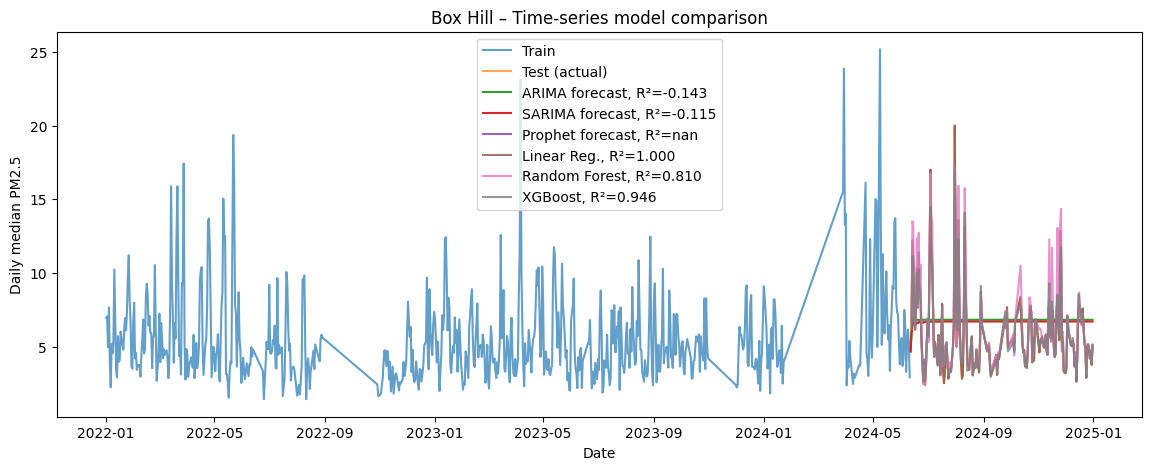


=== Site: Geelong South ===


14:05:51 - cmdstanpy - INFO - Chain [1] start processing
14:05:51 - cmdstanpy - INFO - Chain [1] done processing
14:05:51 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
14:05:51 - cmdstanpy - INFO - Chain [1] start processing
14:05:51 - cmdstanpy - INFO - Chain [1] done processing
14:05:51 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Geelong South: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=41224 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\ke2kfep0.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\1148h78x.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_modelft1wh0ac\prophet_model-20251130140551.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Melton ===


14:05:54 - cmdstanpy - INFO - Chain [1] start processing
14:05:54 - cmdstanpy - INFO - Chain [1] done processing
14:05:54 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
14:05:54 - cmdstanpy - INFO - Chain [1] start processing
14:05:54 - cmdstanpy - INFO - Chain [1] done processing
14:05:54 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Melton: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=70812 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\uobmbeli.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\subeeddb.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_modelzimvxhyg\prophet_model-20251130140554.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Morwell South ===


...

Prophet failed for Newborough: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=11529 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\11vkha8p.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\yiedh50n.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_model81f5eyx7\prophet_model-20251130140609.csv method=optimize algorithm=newton iter=10000' failed: 

=== Site: Campbellfield ===


14:06:10 - cmdstanpy - INFO - Chain [1] start processing
14:06:10 - cmdstanpy - INFO - Chain [1] done processing
14:06:10 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Campbellfield: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=41852 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\o2wtqwa9.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\w3vj4xgw.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_modelyrfk6x1w\prophet_model-20251130140610.csv method=optimize algorithm=newton iter=10000' failed: 
  Skipping lag-based models for Campbellfield: only 69 rows.

=== Site: Bendigo ===


14:06:12 - cmdstanpy - INFO - Chain [1] start processing
14:06:12 - cmdstanpy - INFO - Chain [1] done processing
14:06:12 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 
Optimization terminated abnormally. Falling back to Newton.
14:06:12 - cmdstanpy - INFO - Chain [1] start processing
14:06:12 - cmdstanpy - INFO - Chain [1] done processing
14:06:12 - cmdstanpy - ERROR - Chain [1] error: code '3221225785' 


Prophet failed for Bendigo: Error during optimization! Command 'C:\Users\Christopher\Desktop\Personal Projects\Project 1 Comparing Melbourne's Air Quality\mel-air-norms-now\.venv\Lib\site-packages\prophet\stan_model\prophet_model.bin random seed=92567 data file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\bsh6ntb3.json init=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\4nq8g40z.json output file=C:\Users\CHRIST~1\AppData\Local\Temp\tmph1bi62im\prophet_modelzzg3_y3y\prophet_model-20251130140612.csv method=optimize algorithm=newton iter=10000' failed: 


In [34]:
all_site_metrics = []

example_site_for_plots = "Box Hill"

for site in sites:
    print(f"\n=== Site: {site} ===")

    # ARIMA/SARIMA/Prophet: Univariate series
    site_df = (
        df_pm25[df_pm25["site_name"] == site]
        .sort_values("date")
        .reset_index(drop=True)
    )

    y_series = site_df["daily_median"].astype(float)
    dates = site_df["date"]

    n = len(y_series)
    if n < 50:
        print(f"  Skipping ARIMA/SARIMA/Prophet: only {n} rows.")
        mae_arima = rmse_arima = r2_arima = np.nan
        mae_sarima = rmse_sarima = r2_sarima = np.nan
        mae_prophet = rmse_prophet = r2_prophet = np.nan
        y_train = y_test = dates_train = dates_test = pd.Series([], dtype=float)
    else:
        split_idx = int((1 - test_frac) * n)

        y_train, y_test = y_series.iloc[:split_idx], y_series.iloc[split_idx:]
        dates_train, dates_test = dates.iloc[:split_idx], dates.iloc[split_idx:]

        # ARIMA
        try:
            arima_model = ARIMA(y_train, order=arima_order)
            arima_res = arima_model.fit()
            arima_forecast = arima_res.forecast(steps=len(y_test))
            mae_arima, rmse_arima, r2_arima = eval_forecast(y_test, arima_forecast)
        except Exception as e:
            print(f"ARIMA failed for {site}: {e}")
            mae_arima = rmse_arima = r2_arima = np.nan
            arima_forecast = pd.Series(index=y_test.index, data=np.nan  )

        # SARIMA 
        try:
            sarima_model = SARIMAX(
                y_train,
                order=sarima_order,
                seasonal_order=sarima_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            sarima_res = sarima_model.fit(disp=False)
            sarima_forecast = sarima_res.forecast(steps=len(y_test))
            mae_sarima, rmse_sarima, r2_sarima = eval_forecast(y_test, sarima_forecast)
        except Exception as e:
            print(f"SARIMA failed for {site}: {e}")
            mae_sarima = rmse_sarima = r2_sarima = np.nan
            sarima_forecast = pd.Series(index=y_test.index, data=np.nan)

        # Prophet 
        try:
            # Prophet needs a clean date + y dataframe
            df_prophet = pd.DataFrame({
                "ds": dates,
                "y": y_series,
            })

            df_prophet_train = df_prophet.iloc[:split_idx].copy()
            df_prophet_test = df_prophet.iloc[split_idx:].copy()

            m = Prophet()
            m.fit(df_prophet_train)

            future = df_prophet_test[["ds"]]  # forecast exactly on test dates
            forecast_prophet = m.predict(future)
            prophet_pred = forecast_prophet["yhat"].values

            mae_prophet, rmse_prophet, r2_prophet = eval_forecast(
                df_prophet_test["y"].values, prophet_pred
            )
        except Exception as e:
            print(f"Prophet failed for {site}: {e}")
            mae_prophet = rmse_prophet = r2_prophet = np.nan
            prophet_pred = np.full(len(y_test), np.nan)

    # Models with lag features (XGB + LR + RF)
    # use df_lagged (no missing lags) but subset for this site
    site_lagged = (
        df_lagged[df_lagged["site_name"] == site]
        .sort_values("date")
        .reset_index(drop=True)
    )

    n_lag = len(site_lagged)

    if n_lag < 100:
        print(f"  Skipping lag-based models for {site}: only {n_lag} rows.")
        mae_xgb = rmse_xgb = r2_xgb = np.nan
        mae_lr = rmse_lr = r2_lr = np.nan
        mae_rf = rmse_rf = r2_rf = np.nan
        xgb_pred = lr_pred = rf_pred = np.full(len(y_test), np.nan)
    else:
        X_site = site_lagged[xgb_features].astype(float)
        y_site = site_lagged["daily_median"].astype(float)

        n_lag = len(y_site)
        split_idx_lag = int((1 - test_frac) * n_lag)

        X_train_ml, X_test_ml = X_site.iloc[:split_idx_lag], X_site.iloc[split_idx_lag:]
        y_train_ml, y_test_ml = y_site.iloc[:split_idx_lag], y_site.iloc[split_idx_lag:]

        dates_lag = site_lagged["date"]
        dates_lag_test = dates_lag.iloc[split_idx_lag:]

        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_train_ml, y_train_ml)
        pred_lr = lr.predict(X_test_ml)
        mae_lr, rmse_lr, r2_lr = eval_forecast(y_test_ml, pred_lr)

        # Random Forest
        rf = RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            min_samples_leaf=5,
        )
        rf.fit(X_train_ml, y_train_ml)
        rf_pred = rf.predict(X_test_ml)
        mae_rf, rmse_rf, r2_rf = eval_forecast(y_test_ml, rf_pred)

        try:
            xgb = XGBRegressor(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
            )
            xgb.fit(X_train_ml, y_train_ml)
            xgb_pred = xgb.predict(X_test_ml)

            mae_xgb, rmse_xgb, r2_xgb = eval_forecast(y_test_ml, xgb_pred)
        except Exception as e:
            print(f"XGBoost failed for {site}: {e}")
            mae_xgb = rmse_xgb = r2_xgb = np.nan
            xgb_pred = np.full(len(y_test_ml), np.nan)

    # Save metrics
    all_site_metrics.append({
        "site": site,
        "mae_arima": mae_arima,   "rmse_arima": rmse_arima,   "r2_arima": r2_arima,
        "mae_sarima": mae_sarima, "rmse_sarima": rmse_sarima, "r2_sarima": r2_sarima,
        "mae_prophet": mae_prophet, "rmse_prophet": rmse_prophet, "r2_prophet": r2_prophet,
        "mae_lr": mae_lr, "rmse_lr": rmse_lr, "r2_lr": r2_lr,
        "mae_rf": mae_rf, "rmse_rf": rmse_rf, "r2_rf": r2_rf,
        "mae_xgb": mae_xgb, "rmse_xgb": rmse_xgb, "r2_xgb": r2_xgb,
    })


    # Plot for one example site
    if site == example_site_for_plots and len(y_test) > 0:
        plt.figure(figsize=(14, 5))
        plt.plot(dates_train, y_train, label="Train", alpha=0.7)
        plt.plot(dates_test,  y_test,  label="Test (actual)", alpha=0.7)

        plt.plot(dates_test, arima_forecast,
                 label=f"ARIMA forecast, R²={r2_arima:.3f}")
        plt.plot(dates_test, sarima_forecast,
                 label=f"SARIMA forecast, R²={r2_sarima:.3f}")
        plt.plot(dates_test, prophet_pred,
                 label=f"Prophet forecast, R²={r2_prophet:.3f}")

        # For LR / RF / XGB: use the lagged test dates
        plt.plot(dates_lag_test, pred_lr,
                 label=f"Linear Reg., R²={r2_lr:.3f}", alpha=0.8)
        plt.plot(dates_lag_test, rf_pred,
                 label=f"Random Forest, R²={r2_rf:.3f}", alpha=0.8)
        plt.plot(dates_lag_test, xgb_pred,
                 label=f"XGBoost, R²={r2_xgb:.3f}", alpha=0.8)

        plt.legend()
        plt.title(f"{site} – Time-series model comparison")
        plt.ylabel("Daily median PM2.5")
        plt.xlabel("Date")
        plt.show()

In [35]:
metrics_ts_all = pd.DataFrame(all_site_metrics)
metrics_ts_all.head()

,site,mae_arima,rmse_arima,r2_arima,mae_sarima,rmse_sarima,r2_sarima,mae_prophet,rmse_prophet,r2_prophet,mae_lr,rmse_lr,r2_lr,mae_rf,rmse_rf,r2_rf,mae_xgb,rmse_xgb,r2_xgb
0,Alphington,3.366867,4.978443,-0.022647,3.365876,4.978964,-0.022861,NaN,NaN,NaN,1.149678e-14,1.308218e-14,1.0,0.468440,1.005816,0.958329,0.451420,0.952192,0.962653
1,Footscray,2.286127,2.944946,-0.006959,2.433570,2.982958,-0.033122,NaN,NaN,NaN,1.660190e-14,1.920175e-14,1.0,0.298911,0.928514,0.899900,0.255861,0.421226,0.979399
2,Brighton,2.441379,3.121444,-0.002429,2.463354,3.127702,-0.006452,NaN,NaN,NaN,3.592915e-14,4.053107e-14,1.0,0.439904,0.820626,0.931049,0.359838,0.638235,0.958293
3,Traralgon,2.060534,2.851291,-0.010382,2.057449,2.852930,-0.011544,NaN,NaN,NaN,2.293100e-14,2.739397e-14,1.0,0.464594,2.116822,0.443108,0.324223,0.546646,0.962862
4,Morwell East,1.668630,2.059948,-0.033153,2.409255,2.868980,-1.004045,NaN,NaN,NaN,3.356402e-13,3.418523e-13,1.0,1.579977,3.047332,-1.260955,2.155036,5.889597,-7.445462


In [ ]:
summary_by_model = pd.DataFrame({
    "model": ["ARIMA", "SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        metrics_ts_all["mae_arima"].mean(),
        metrics_ts_all["mae_sarima"].mean(),
        metrics_ts_all["mae_prophet"].mean(),
        metrics_ts_all["mae_xgb"].mean(),
    ],
    "RMSE": [
        metrics_ts_all["rmse_arima"].mean(),
        metrics_ts_all["rmse_sarima"].mean(),
        metrics_ts_all["rmse_prophet"].mean(),
        metrics_ts_all["rmse_xgb"].mean(),
    ],
    "R2": [
        metrics_ts_all["r2_arima"].mean(),
        metrics_ts_all["r2_sarima"].mean(),
        metrics_ts_all["r2_prophet"].mean(),
        metrics_ts_all["r2_xgb"].mean(),
    ],
})
summary_by_model


,model,MAE,RMSE,R2
0,ARIMA,2.122966,2.813045,-0.103609
1,SARIMA,2.266063,2.957135,-0.252875
2,Prophet,NaN,NaN,NaN
3,XGBoost,0.483637,1.150862,0.252679
